In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('titanic.csv')

Top 5 rows hernu paryo bhane df.head use garne 

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last five rows hernu cha bhane ke garne 


In [5]:
df.head(-1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
missing=df.isnull().sum()
print(missing[missing>0].sort_values(ascending=False))



Cabin       687
Age         177
Embarked      2
dtype: int64


Kun kun rows haru duplicated cha identify garnu paryo kina bhane paxi hamilai at least different ml algorithm le different roles haru play garcha most of the case falidincha manche le

In [10]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


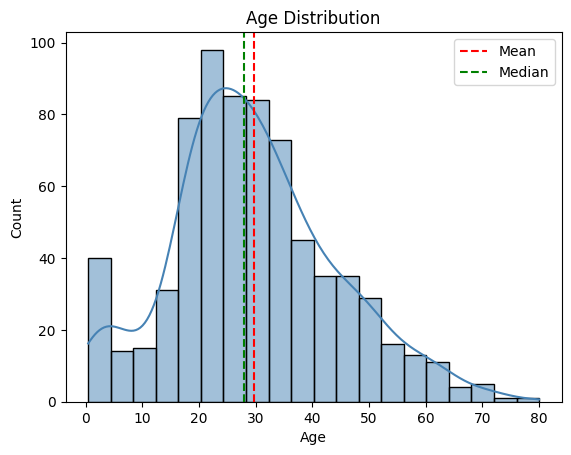

In [16]:
# sns.histplot(df['Age'],kde=True, color='steelblue')
# plt.axvline(df['Age'].mean(),color="red", linestyle='--', label="mean") 
# plt.axvline(df['Age'].median(),color="green", linestyle='--', label="median")
# plt.legend();
# plt.title('Age Distribution')
# plt.show()


sns.histplot(df['Age'], kde=True, color='steelblue')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Median')

plt.legend()
plt.title('Age Distribution')
plt.show()


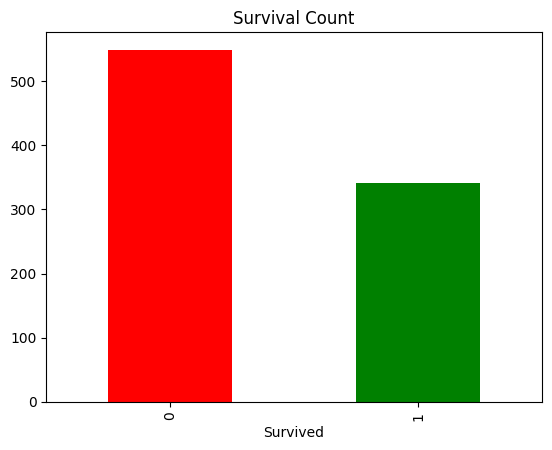

In [18]:
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')
plt.show()

Multivariate analysis

<Axes: xlabel='Sex'>

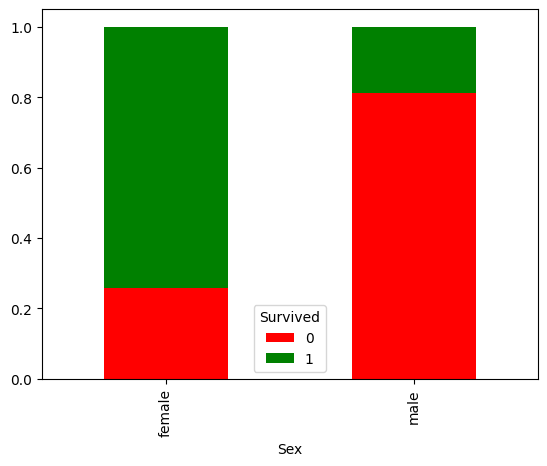

In [20]:
ct= pd.crosstab(df['Sex'],df['Survived'], normalize='index')
ct.plot(kind='bar', stacked=True, color=['red', 'green'])

In [24]:
survived=df['Survived'].mean()*100
print(survived)

38.38383838383838


In [26]:
sex_survived=(df.groupby('Sex')['Survived'].mean()*100).round(1)
print(sex_survived)

Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [28]:
class_survived=(df.groupby('Pclass')['Survived'].mean()*100).round(1)
print(class_survived)

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [29]:
df['child']=df['Age']<18
child_survived=(df.groupby('child')['Survived'].mean()*100).round(1)
print(child_survived)

child
False    36.1
True     54.0
Name: Survived, dtype: float64
